In [58]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from pandas_ta.volatility import kc 
import enum
from zoneinfo import ZoneInfo
from datetime import datetime, timezone

class POSITION(enum.Enum):
    NEUTRAL = 0
    LONG = 1
    SHORT = 2
    
class EMA25(enum.Enum):
    PRICE_ACCION_NEUTRAL = 0
    PRICE_ACCION_UNDER = 1
    PRICE_ACCION_OVER = 2

def calculateBolingerAndKeltnerChannels(kc)->None:
    # Bolinger Bands
    df.ta.bbands(append=True, length=20, std=2)
    
    # Initialize Keltner Channel Indictor
    kc=kc(high=df['High'], low=df['Low'], close=df["Close"], window=20)
    
    #Bolinger Band Upper - Keltner Channel Upper
    df['bbu_minus_kcu'] = df['BBU_20_2.0'] - kc['KCUe_20_2']
    
def detectPosibleBreak(candle)->None:
    
    window = 3
    posibleBreak = EMA25['PRICE_ACCION_NEUTRAL'].value
    ema25 = (df.iloc[candle]).ema25
    close = (df.iloc[candle]).Close 
    squeezeCloseToEma = (df.iloc[candle]).squeezeCloseToEma 
    
    if (candle <= (window)) or (candle+window+1 >= len(df)):
        return posibleBreak
    
    df2 = df.iloc[candle-window:candle]
    
    lastTreeUnder = df2[df2['squeezeCloseToEma'] == EMA25['PRICE_ACCION_UNDER'].value].tail(3).values
    lastTreeOver = df2[df2['squeezeCloseToEma'] == EMA25['PRICE_ACCION_OVER'].value].tail(3).values

    if len(lastTreeUnder) == window and close<ema25 and squeezeCloseToEma:
        posibleBreak = EMA25['PRICE_ACCION_UNDER'].value
    elif len(lastTreeOver) == window and close>ema25 and squeezeCloseToEma:
        posibleBreak = EMA25['PRICE_ACCION_OVER'].value
    else:
        posibleBreak = EMA25['PRICE_ACCION_NEUTRAL'].value
            
    return posibleBreak


def detectSqueezeCloseToEMA(zoneWidth = .30)->None:

    df['squeezeCloseToEma'] = EMA25['PRICE_ACCION_NEUTRAL'].value
    
    cond =((df.squeezedArea == EMA25['PRICE_ACCION_OVER'].value) & (abs(df.Low-df.ema25)<=zoneWidth))
    df.loc[cond, 'squeezeCloseToEma'] = EMA25['PRICE_ACCION_OVER'].value

    cond =((df.squeezedArea == EMA25['PRICE_ACCION_UNDER'].value) & (abs(df.High-df.ema25)<=zoneWidth))
    df.loc[cond, 'squeezeCloseToEma'] = EMA25['PRICE_ACCION_UNDER'].value
    
def detectSqueeze()->None:
    
    df['squeezedArea'] = EMA25['PRICE_ACCION_NEUTRAL'].value
    cond = ((df.bbu_minus_kcu <= 0) & (df.Close < df.ema25))
    df.loc[cond, 'squeezedArea'] = EMA25['PRICE_ACCION_UNDER'].value
    
    cond2 =((df.bbu_minus_kcu <= 0) & (df.Close > df.ema25))
    df.loc[cond2, 'squeezedArea'] = EMA25['PRICE_ACCION_OVER'].value

if __name__ == '__main__':
    
    df = pd.read_csv("../data/MSFT/MSFT.USUSD_Candlestick_5_M_BID_01.09.2022-21.09.2024.csv")
    df=df[0:20000]
    df=df[df['Volume']!=0]
    
    df["Gmt time"]=df["Gmt time"].str.replace(".000","")
    df['Gmt time']=pd.to_datetime(df['Gmt time'],format='%d.%m.%Y %H:%M:%S')
    df.rename(columns = {'Gmt time':'datetime_gmt'}, inplace = True)
    df['datetime_est']=pd.to_datetime(df["datetime_gmt"], unit='ms').dt.tz_localize('UTC').dt.tz_convert('US/Eastern')

    # Regular hours
    df.index = df['datetime_est']
    df.between_time("09:30", "16:00")
    
    df['ema25'] = df['Close'].ewm(span=25, adjust=False).mean()
    df=df[df.High!=df.Low]
    
    df.reset_index(drop=True, inplace=True)
    pd.options.mode.copy_on_write = True

    calculateBolingerAndKeltnerChannels(kc)
    detectSqueeze()
    detectSqueezeCloseToEMA()
   
    df['posibleBreak'] = df.apply(lambda row: detectPosibleBreak(row.name), axis=1)
    
    df = df[['datetime_est','Open','High','Low','Close','Volume','ema25','squeezedArea','squeezeCloseToEma','posibleBreak']]
    #result = df.loc[df["posibleBreak"]==1]
    print(df.tail(10))

               datetime_est     Open     High      Low    Close  Volume  \
0 2022-09-01 09:30:00-04:00  259.337  259.547  257.896  257.927  2.0268   
1 2022-09-01 09:35:00-04:00  257.967  258.957  257.926  258.576  2.2260   
2 2022-09-01 09:40:00-04:00  258.547  259.377  258.396  258.737  2.2716   
3 2022-09-01 09:45:00-04:00  258.687  259.277  258.466  258.766  2.7444   
4 2022-09-01 09:50:00-04:00  258.726  259.147  258.496  259.087  2.4504   
5 2022-09-01 09:55:00-04:00  259.086  259.557  258.516  259.396  2.1108   
6 2022-09-01 10:00:00-04:00  259.397  259.797  258.256  258.326  3.0468   
7 2022-09-01 10:05:00-04:00  258.327  258.757  258.156  258.336  2.5692   
8 2022-09-01 10:10:00-04:00  258.336  258.517  257.696  257.706  2.3616   
9 2022-09-01 10:15:00-04:00  257.707  257.847  257.496  257.746  2.1732   

        ema25  squeezedArea  squeezeCloseToEma  posibleBreak  
0  257.927000             0                  0             0  
1  257.976923             0                  0  

In [56]:
def posibleBreakArea(x):
    extraSpace = 1
    if (x['posibleBreak']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['posibleBreak']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace    
    else:
        return np.nan
        
def squeezeCloseToEmaArea(x):
    extraSpace = .80
    if (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['squeezeCloseToEma']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace
    else:
        return np.nan
        
def squezzeArea(x):
    extraSpace = .50
    if (x['squeezedArea']==EMA25['PRICE_ACCION_OVER'].value):
        return x['Low']-extraSpace
    elif (x['squeezedArea']==EMA25['PRICE_ACCION_UNDER'].value):
        return x['High']+extraSpace
    else:
        return np.nan

df['squezzeArea'] = df.apply(lambda row: squezzeArea(row), axis=1)
df['squeezeCloseToEmaArea'] = df.apply(lambda row: squeezeCloseToEmaArea(row), axis=1)
df['posibleBreakArea'] = df.apply(lambda row: posibleBreakArea(row), axis=1)

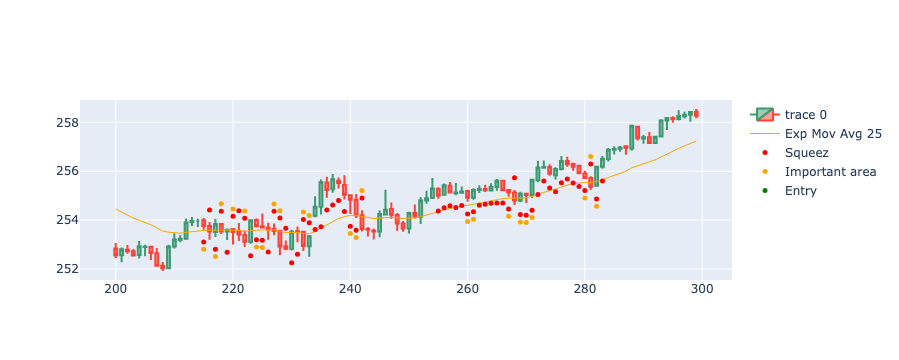

In [57]:
import plotly.io as pio
import plotly.graph_objects as go  

dfpl = df[200:300]

fig = go.Figure(
    data=[
        go.Candlestick(
            x=dfpl.index,
            open=dfpl['Open'],
            high=dfpl['High'],
            low=dfpl['Low'],
            close=dfpl['Close']),
        go.Scatter(
            x=dfpl.index, 
            y=dfpl['ema25'],
            line=dict(color='orange', width=1), 
            name="Exp Mov Avg 25")
    ]
)

fig.add_scatter(x=dfpl.index, y=dfpl['squezzeArea'], mode="markers", marker=dict(size=5, color="red"), name="Squeez")
fig.add_scatter(x=dfpl.index, y=dfpl['squeezeCloseToEmaArea'], mode="markers", marker=dict(size=5, color="orange"), name="Important area")
fig.add_scatter(x=dfpl.index, y=dfpl['posibleBreakArea'], mode="markers", marker=dict(size=5, color="green"), name="Entry")

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()
